### Grover's Algorithm
Quantum algorithm for unstructured search that finds something with high probability in O(√N) faster than classical counterpart which takes O(N)

In [ ]:
# initialization
import matplotlib.pyplot as plt
import numpy as np
import math

# importing Qiskit
from qiskit import IBMQ, Aer, execute
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile, assemble

# import basic plot tools
from qiskit.visualization import plot_histogram

In [81]:
#Create a list of possible inputs
marked_strings = ['00', '01', '10']

#Define grover's diffuser
def grover_diffusion(qc, qubits):
    qc.h(qubits)
    qc.x(qubits)
    qc.cz(qubits[0], qubits[1])
    qc.x(qubits)
    qc.h(qubits)

#Define oracle's for potential input states
def oracle_for_00_state(qc, qubits):
    qc.x(qubits)
    qc.cz(qubits[0], qubits[1])
    qc.x(qubits)

def oracle_for_01_state(qc, qubits):
    qc.x(qubits[1])  
    qc.cz(qubits[0], qubits[1])
    qc.x(qubits[1])

def oracle_for_10_state(qc, qubits):
    qc.x(qubits[0])  
    qc.cz(qubits[0], qubits[1])
    qc.x(qubits[0])

# Create the Grover's algorithm circuit
def grover_circuit(a):
    #Create a Quantum Circuit
    gc = QuantumCircuit(2, 2)
    
    #Apply Hadamard gates to all registers
    gc.h(range(2))

    #Number of iterations
    n = 2
    t = int((math.pi/4)*2**(n/2))

    #Apply grovers for the proper number of iterations
    for _ in range(t):
        if a == '00':
            oracle_for_00_state(gc, [0, 1])
            grover_diffusion(gc, [0, 1])
        if a == '01':
            oracle_for_01_state(gc, [0, 1])
            grover_diffusion(gc, [0, 1])
        if a == '10':
            oracle_for_10_state(gc, [0, 1])
            grover_diffusion(gc, [0, 1])
    
    #Measure both qubits
    gc.measure(range(2), range(2))

    #Draw the circuit
    gc.draw(output="mpl")
    
    return gc 

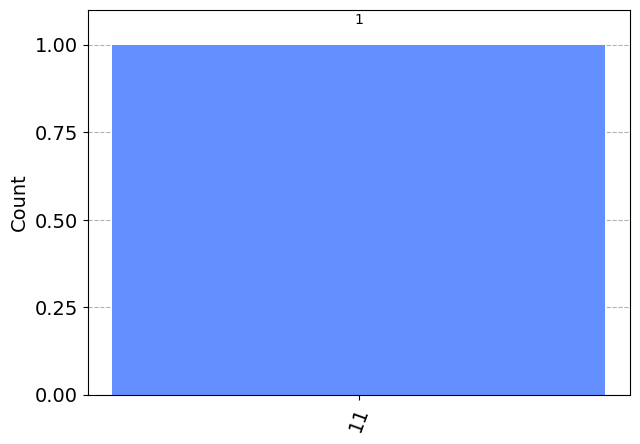

In [83]:
#Run simulation
backend = Aer.get_backend("qasm_simulator")

output = grover_circuit('00')
results = execute(output, backend, shots=1024).result()
answer = result.get_counts()

plot_histogram(answer)

output = grover_circuit('01')
results = execute(output, backend, shots=1024).result()
answer = result.get_counts()

plot_histogram(answer10)

output = grover_circuit('10')
results = execute(output, backend, shots=1024).result()
answer = result.get_counts()

plot_histogram(answer)